In [7]:
import torch 
import torch.nn as nn

In [8]:
x = torch.tensor([1.0,2.0,3.0])
w = torch.tensor([0.1,0.2,0.3])
b = torch.tensor(0.5)

In [9]:
z = torch.dot(w,x) + b
z

# tensor(1.9000)

tensor(1.9000)

In [ ]:
sigmoid = nn.Sigmoid()
output = sigmoid(z)
output
# tensor(0.8699)

tensor(0.8699)

In [12]:
import torch.optim as optim
import matplotlib.pyplot as plt

torch.Size([8, 1])
torch.Size([8, 1])


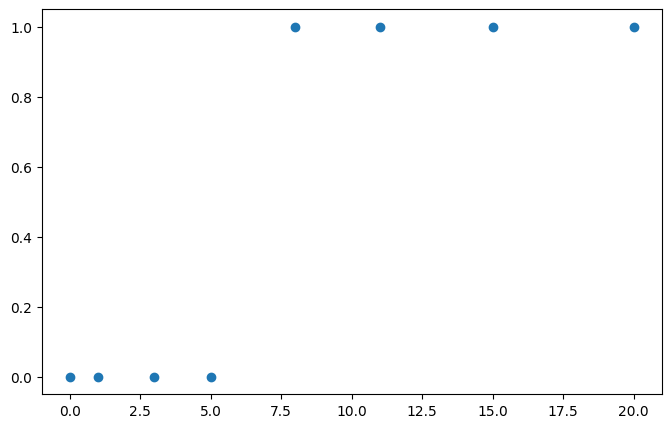

In [ ]:
torch.manual_seed(2025)

x_train = torch.FloatTensor([[0], [1], [3], [5], [8], [11], [15], [20]])
y_train = torch.FloatTensor([[0], [0], [0], [0], [1], [1], [1], [1]])
print(x_train.shape)
print(y_train.shape)
# torch.Size([8, 1])
# torch.Size([8, 1])

plt.figure(figsize=(8, 5))
plt.scatter(x_train, y_train)

In [25]:
model = nn.Sequential(
    nn.Linear(1,1),
    nn.Sigmoid()
)

In [26]:
list(model.parameters())

[Parameter containing:
 tensor([[0.4941]], requires_grad=True),
 Parameter containing:
 tensor([-0.9571], requires_grad=True)]

In [27]:
y_pred = model(x_train)
y_pred
# tensor([[4.4972e-01],
#         [3.4939e-01],
#         [1.8823e-01],
#         [9.1004e-02],
#         [2.7620e-02],
#         [7.9943e-03],
#         [1.5001e-03],
#         [1.8401e-04]], grad_fn=<SigmoidBackward0>)


tensor([[0.2775],
        [0.3863],
        [0.6284],
        [0.8196],
        [0.9524],
        [0.9888],
        [0.9984],
        [0.9999]], grad_fn=<SigmoidBackward0>)

In [ ]:
loss = nn.BCELoss()(y_pred, y_train)
loss

# tensor(0.4471, grad_fn=<BinaryCrossEntropyBackward0>)

tensor(0.4471, grad_fn=<BinaryCrossEntropyBackward0>)

In [ ]:
optimizer = optim.SGD(model.parameters(), lr = 0.01)

epochs = 1000

for epoch in range (epochs + 1):
    y_pred = model(x_train)
    loss = nn.BCELoss()(y_pred, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 100 == 0:
        print(f'epoch: {epoch}/{epochs} Loss: {loss: .6f}')

# epoch: 0/1000 Loss:  0.447143
# epoch: 100/1000 Loss:  0.313473
# epoch: 200/1000 Loss:  0.296310
# epoch: 300/1000 Loss:  0.281232
# epoch: 400/1000 Loss:  0.267894
# epoch: 500/1000 Loss:  0.256020
# epoch: 600/1000 Loss:  0.245387
# epoch: 700/1000 Loss:  0.235812
# epoch: 800/1000 Loss:  0.227145
# epoch: 900/1000 Loss:  0.219263
# epoch: 1000/1000 Loss:  0.212061

epoch: 0/1000 Loss:  0.447143
epoch: 100/1000 Loss:  0.313473
epoch: 200/1000 Loss:  0.296310
epoch: 300/1000 Loss:  0.281232
epoch: 400/1000 Loss:  0.267894
epoch: 500/1000 Loss:  0.256020
epoch: 600/1000 Loss:  0.245387
epoch: 700/1000 Loss:  0.235812
epoch: 800/1000 Loss:  0.227145
epoch: 900/1000 Loss:  0.219263
epoch: 1000/1000 Loss:  0.212061


In [ ]:
list(model.parameters())

# W: [0.3921]
# B: [-2.0678]

[Parameter containing:
 tensor([[0.3921]], requires_grad=True),
 Parameter containing:
 tensor([-2.0678], requires_grad=True)]

In [ ]:
x_test = torch.FloatTensor([[10]])
y_pred = model(x_test)
y_pred

# tensor([[0.8645]], grad_fn=<SigmoidBackward0>)

y_bool = (y_pred >= 0.5).float()
y_bool

# tensor([[1.]])

tensor([[1.]])

In [ ]:
x_train = [[1, 2, 1, 1],
           [2, 1, 3, 2],
           [3, 1, 3, 4],
           [4, 2, 5, 5],
           [1, 6, 5, 5],
           [1, 4, 5, 8],
           [1, 7, 7, 7],
           [2, 8, 7, 8],
           [2, 7, 6, 7],
           [2, 6, 6, 6]]

y_train = [0, 0, 0, 1, 1, 1, 2, 2, 2, 2]

x_train = torch.FloatTensor(x_train)
y_train = torch.LongTensor(y_train)
print(x_train.shape)
print(y_train.shape)

# torch.Size([10, 4])
# torch.Size([10])

torch.Size([10, 4])
torch.Size([10])


In [34]:
model = nn.Sequential(
    nn.Linear(4, 3)
)
model

Sequential(
  (0): Linear(in_features=4, out_features=3, bias=True)
)

In [ ]:
list(model.parameters())

# [Parameter containing:
#  tensor([[-0.4346,  0.2855, -0.1117,  0.1340],
#          [ 0.4447, -0.0227, -0.2139, -0.1113],
#          [-0.3901, -0.1394,  0.3450,  0.3059]], requires_grad=True),
#  Parameter containing:
#  tensor([-0.4480, -0.1562,  0.0326], requires_grad=True)]

[Parameter containing:
 tensor([[-0.4346,  0.2855, -0.1117,  0.1340],
         [ 0.4447, -0.0227, -0.2139, -0.1113],
         [-0.3901, -0.1394,  0.3450,  0.3059]], requires_grad=True),
 Parameter containing:
 tensor([-0.4480, -0.1562,  0.0326], requires_grad=True)]

In [ ]:
y_pred = model(x_train)
y_pred

# tensor([[-0.2892, -0.0821,  0.0146],
#         [-1.0986, -0.1538,  0.7598],
#         [-1.2651,  0.0684,  0.9815],
#         [-1.5035, -0.0487,  1.4479],
#         [ 0.9420, -1.4737,  2.0605],
#         [ 0.7732, -1.7621,  3.2569],
#         [ 1.2722, -2.1468,  3.2229],
#         [ 1.2571, -1.8361,  2.9992],
#         [ 0.9493, -1.4882,  2.4878],
#         [ 0.5298, -1.3542,  2.3213]], grad_fn=<AddmmBackward0>)

tensor([[-0.2892, -0.0821,  0.0146],
        [-1.0986, -0.1538,  0.7598],
        [-1.2651,  0.0684,  0.9815],
        [-1.5035, -0.0487,  1.4479],
        [ 0.9420, -1.4737,  2.0605],
        [ 0.7732, -1.7621,  3.2569],
        [ 1.2722, -2.1468,  3.2229],
        [ 1.2571, -1.8361,  2.9992],
        [ 0.9493, -1.4882,  2.4878],
        [ 0.5298, -1.3542,  2.3213]], grad_fn=<AddmmBackward0>)

In [ ]:
loss = nn.CrossEntropyLoss()(y_pred, y_train)
loss

# tensor(1.7610, grad_fn=<NllLossBackward0>)

tensor(1.7610, grad_fn=<NllLossBackward0>)

In [38]:
optimizer = optim.SGD(model.parameters(),lr = 0.01)

In [ ]:
epochs = 10000

for epoch in range(epochs + 1):
    y_pred = model(x_train)
    loss = nn.CrossEntropyLoss()(y_pred, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 100 == 0:
        print(f'epoch: {epoch} / {epochs}, loss: {loss: .6f}')
# ...
# epoch: 9700 / 10000, loss:  0.347429
# epoch: 9800 / 10000, loss:  0.346335
# epoch: 9900 / 10000, loss:  0.345250
# epoch: 10000 / 10000, loss:  0.344174        

epoch: 0 / 10000, loss:  1.760977
epoch: 100 / 10000, loss:  0.960568
epoch: 200 / 10000, loss:  0.787511
epoch: 300 / 10000, loss:  0.713568
epoch: 400 / 10000, loss:  0.673414
epoch: 500 / 10000, loss:  0.646685
epoch: 600 / 10000, loss:  0.626429
epoch: 700 / 10000, loss:  0.609869
epoch: 800 / 10000, loss:  0.595724
epoch: 900 / 10000, loss:  0.583322
epoch: 1000 / 10000, loss:  0.572264
epoch: 1100 / 10000, loss:  0.562290
epoch: 1200 / 10000, loss:  0.553218
epoch: 1300 / 10000, loss:  0.544911
epoch: 1400 / 10000, loss:  0.537259
epoch: 1500 / 10000, loss:  0.530178
epoch: 1600 / 10000, loss:  0.523597
epoch: 1700 / 10000, loss:  0.517454
epoch: 1800 / 10000, loss:  0.511702
epoch: 1900 / 10000, loss:  0.506296
epoch: 2000 / 10000, loss:  0.501200
epoch: 2100 / 10000, loss:  0.496382
epoch: 2200 / 10000, loss:  0.491815
epoch: 2300 / 10000, loss:  0.487475
epoch: 2400 / 10000, loss:  0.483341
epoch: 2500 / 10000, loss:  0.479394
epoch: 2600 / 10000, loss:  0.475618
epoch: 2700 /

In [ ]:
x_test = torch.FloatTensor([[1,9,9,8]])
y_pred = model(x_test)
y_pred
# tensor([[-11.2851,   5.6718,   8.5757]], grad_fn=<AddmmBackward0>)

tensor([[-11.2851,   5.6718,   8.5757]], grad_fn=<AddmmBackward0>)

In [ ]:
y_prob = nn.Softmax(1)(y_pred)
y_prob

# tensor([[2.2459e-09, 5.1957e-02, 9.4804e-01]], grad_fn=<SoftmaxBackward0>)

tensor([[2.2459e-09, 5.1957e-02, 9.4804e-01]], grad_fn=<SoftmaxBackward0>)

In [ ]:
print(f'0일 확률: {y_prob[0][0]:.2f}')
print(f'1일 확률: {y_prob[0][1]:.2f}')
print(f'2일 확률: {y_prob[0][2]:.2f}')

torch.argmax(y_prob, axis=1)

# 0일 확률: 0.00
# 1일 확률: 0.05
# 2일 확률: 0.95
# tensor([2])

0일 확률: 0.00
1일 확률: 0.05
2일 확률: 0.95


tensor([2])